In [54]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN
from typing import Callable
import networkx as nx
from sklearn.neighbors import NearestNeighbors


# Mapper Algorithm on Noisy Annuli with Bridge

In this project, we implemented the Mapper algorithm on a dataset consisting of two noisy annuli connected by a bridge. 

The goal of this Problem is to recover the underlying topological structure of the dataset using topological data analysis techniques. The dataset is not linearly separable and contains noise, making it a good example for testing the robustness of the Mapper algorithm.

The Mapper algorithm allows us to extract the shape of the data by combining:
- A filter (lens) function,
- A cover of the filter values,
- A clustering algorithm,
- And a rule to connect clusters based on shared data points.

We used DBSCAN as the clustering algorithm because it can detect non-convex shapes and is robust to noise.


In [55]:
def lens(X):
    return X.iloc[:, 0].to_numpy()


def make_interval_cover(lens_values, n_intervals=12, overlap=0.3):
    min_val = lens_values.min()
    max_val = lens_values.max()

    padding = 0.1 * (max_val - min_val)
    min_val -= padding
    max_val += padding

    step = (max_val - min_val) / n_intervals
    overlap_amount = step * overlap

    cover_set = []

    for i in range(n_intervals):
        a = min_val + i * step - (overlap_amount if i > 0 else 0)
        b = min_val + (i + 1) * step + (overlap_amount if i < n_intervals - 1 else 0)

        cover_set.append((a, b))
    return cover_set

def plot_mapper_graph(vertex_set, edge_set, title="Mapper Graph"):
    G = nx.Graph()

    for i in range(len(vertex_set)):
        G.add_node(i)

    vertex_lookup = {frozenset(v): i for i, v in enumerate(vertex_set)}

    for v1, v2 in edge_set:
        i = vertex_lookup[frozenset(v1)]
        j = vertex_lookup[frozenset(v2)]
        G.add_edge(i, j)

    node_sizes = [max(100, len(v) * 1) for v in vertex_set]

    if len(G.nodes) == 0:
        print("Empty Mapper graph.")
        return

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)

    nx.draw(G,
            pos,
            with_labels=True,
            node_size=node_sizes,
            font_size=10)

    plt.title(title)
    plt.show()


def mapper(data: pd.DataFrame, lens: Callable, cover_set: list, clustering_alg: DBSCAN):
    vertex_set = []
    edge_set = []

    lens_values = lens(data)

    for i, Ui in enumerate(cover_set):
        ax, bx = Ui
        Xi = data[(lens_values >= ax) & (lens_values <= bx)]

        labels = clustering_alg.fit(Xi).labels_

        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)

        for j, cluster_label in enumerate(sorted(unique_labels)):

            members = Xi.index[labels == cluster_label]
            vertex = set(members)
            vertex_set.append(vertex)


    for i, vertex1 in enumerate(vertex_set):
        for j, vertex2 in enumerate(vertex_set):
            if i < j:
              if vertex1.intersection(vertex2):
                  edge_set.append((vertex1, vertex2))

    return vertex_set, edge_set


In [56]:
df = pd.read_csv('noisy_annuli_bridge.csv')
df.head()

,x,y,label,component
0,-6.617106,1.625012,0,left_annulus
1,-2.509268,-0.798896,0,left_annulus
2,-5.311963,-2.902399,0,left_annulus
3,-7.204998,-1.622039,0,left_annulus
4,-3.461512,2.383244,0,left_annulus


# Understanding the Dataset

The dataset consists of two annuli (ring-shaped structures) connected by a narrow bridge of points.

Geometrically, we observe:
- A left circular ring,
- A right circular ring,
- A dense bridge connecting them.

Topologically, this structure can be interpreted as two loops connected by a path. 

This means the space contains:
- Two one-dimensional holes (from the two rings),
- A connecting structure that links them.

Our objective is to verify whether the Mapper algorithm can recover this connectivity structure from the data.


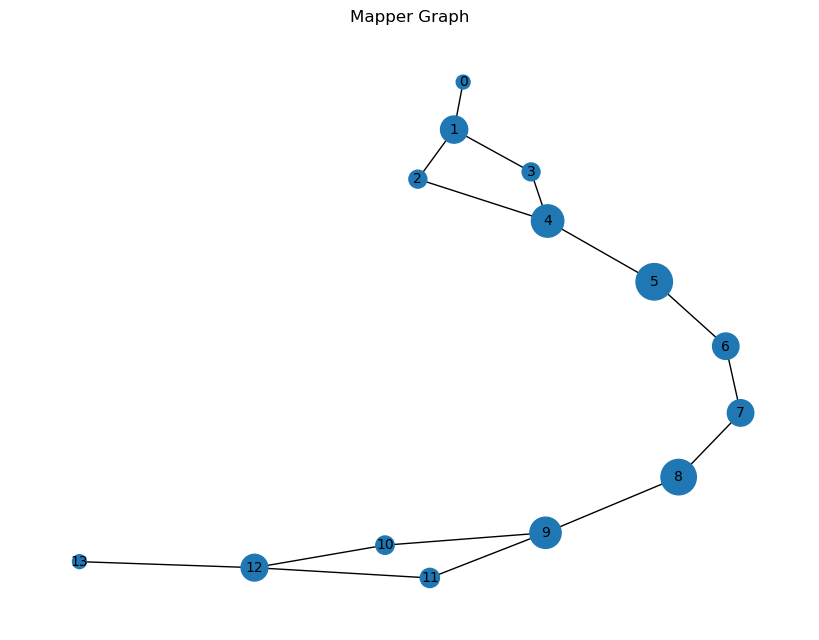

In [68]:
clustering_alg = DBSCAN(eps=0.6, min_samples=5)
data = df[['x', 'y']]


cover_set = make_interval_cover(lens(data), n_intervals=12, overlap=0.3)
vertex_set, edge_set = mapper(data, lens, cover_set, clustering_alg)
plot_mapper_graph(vertex_set, edge_set)

# Sensitivity to Parameters

The Mapper output depends on several parameters:

1. Number of intervals:
   Too few intervals may oversimplify the structure.
   Too many intervals may fragment the graph.

2. Overlap percentage:
   If overlap is too small, the graph may disconnect.
   If overlap is too large, clusters may merge excessively.

3. DBSCAN parameters (eps, min_samples):
   If eps is too small, we obtain too many small clusters.
   If eps is too large, clusters merge and fine structure is lost.

Thus, Mapper provides a flexible but parameter-dependent approximation of topology.


# Constructing the Mapper Graph

Each cluster found inside an interval becomes a vertex in the Mapper graph.

If two clusters (possibly from different intervals) share at least one common data point, we connect their corresponding vertices with an edge.

This happens because of the overlap between intervals.

Thus:

- Vertices represent clusters of points inside slices of the data.
- Edges represent shared data points between clusters.

The resulting graph is a simplicial graph that approximates the topological structure of the dataset.

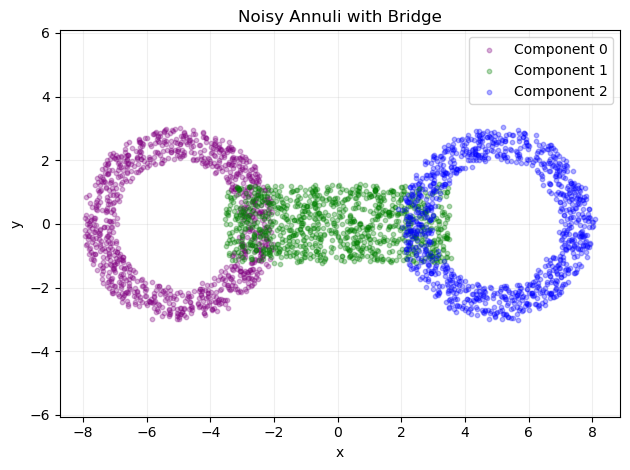

In [72]:
colors = ['purple', 'green', 'blue']
for label, color in enumerate(colors):
    mask = df['label'] == label
    plt.scatter(df.loc[mask, 'x'], df.loc[mask, 'y'],
               color=color, alpha=0.3, s=10, label=f'Component {label}')

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Noisy Annuli with Bridge')
plt.legend()
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.tight_layout()
plt.show()



This Mapper graph shows a sequence of connected nodes that form two larger structures connected by a chain of intermediate nodes.

This reflects the original dataset structure:

- The left part of the graph corresponds to the left annulus.
- The right part corresponds to the right annulus.
- The middle chain corresponds to the bridge connecting the two rings.

Although the graph does not look exactly like two perfect circles, it preserves the connectivity structure of the data.

The essential topological feature captured is:

Two loop-like components connected by a path.

This confirms that the Mapper algorithm successfully recovered the global shape of the dataset.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def dbscan_elbow(X, min_samples=5):
    """
    Plot k-distance graph for DBSCAN epsilon selection.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
    min_samples : int
        DBSCAN min_samples (k in k-distance plot)
    """
    neigh = NearestNeighbors(n_neighbors=min_samples)
    neigh.fit(X)

    distances, _ = neigh.kneighbors(X)
    k_distances = distances[:, -1]  # distance to k-th nearest neighbor
    k_distances = np.sort(k_distances)

    plt.figure(figsize=(6, 4))
    plt.plot(k_distances)
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"{min_samples}-NN distance")
    plt.title("DBSCAN ε Elbow (k-distance plot)")
    plt.grid(True)
    plt.show()

    return k_distances
